# 대규모 모델을 사용하기 위한 API call

**대규모 모델**을 사용할 때 GPU에 구애받지 않고 모델을 inference하기 위한 도구

### API 기반 모델 접근의 장점
- **GPU 제약 없음**: API를 통해 모델에 접근하면, 로컬 하드웨어에 제한을 받지 않음. GPU가 없는 컴퓨터에서도 최신 거대 모델을 활용할 수 있음.
- **간단한 워크플로우**: API를 통해 모델에 접근하면, 모델 최적화 및 유지 관리에 대한 부담 없이 활용에만 집중할 수 있음.

### API 기반 모델 접근의 단점
- **속도 및 지연시간(Latency)**: 네트워크를 통해 요청을 보내고 응답을 받는 시스템이기 때문에, 인터넷 상태에 따라 속도가 달라질 수 있음.
- **비용(Cost)**: 유료임.
- **Fine-tuning**: 사전학습된 모델 자체를 api를 통해 제공하기 때문에, 추가학습에 어려움이 있음.

In [1]:

from transformers import pipeline

# Text Generation using Hugging Face API
text_generator = pipeline('text-generation', model='gpt2')
result = text_generator('Once upon a time in a faraway land,', max_length=50, num_return_sequences=1)
print("Text Generation Result:")
print(result)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Text Generation Result:
[{'generated_text': "Once upon a time in a faraway land, they were so young they couldn't have grown up. They did not become great heroes just because they were famous, but because of the power they possessed. Their parents, who had a strong and powerful"}]


In [2]:

# Sentiment Analysis using Hugging Face API
sentiment_analyzer = pipeline('sentiment-analysis')
sentiment_result = sentiment_analyzer('The movie was absolutely fantastic, I loved it!')
print("\nSentiment Analysis Result:")
print(sentiment_result)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


Sentiment Analysis Result:
[{'label': 'POSITIVE', 'score': 0.9998756647109985}]


In [5]:

# Question Answering using Hugging Face API
question_answerer = pipeline('question-answering', model='distilbert-base-uncased-distilled-squad')
context = "Hugging Face Inc. is a company based in New York City. Its headquarters are in DUMBO, therefore very close to the Manhattan Bridge."
question = "Where is Hugging Face based?"
qa_result = question_answerer(question=question, context=context)
print("\nQuestion Answering Result:")
print(qa_result['answer'])


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



Question Answering Result:
New York City



## Using Groq's API for Large-Scale Model Inference

**Chat Completion**

단순 text generate하는 모델에서, user와 상호작용하는 대화형AI 기반 모델의 수요가 증가함.<br>
 최근 언어모델들은, 대화의 맥락을 파악하고 이에 대한 응답을 생성하는 chat completion 방식을 도입함.

- 프롬프트 (Prompt):
  - 사용자가 모델에 제공하는 입력 텍스트. 대화의 맥락을 제공하는 질문, 문장, 혹은 단어..
- 응답 (Completion):
  - 모델이 프롬프트를 기반으로 생성하는 텍스트
- 대화 맥락 유지
  chat completion은 일반적으로 이전 대화의 맥락을 기억하여, 대화가 자연스럽게 이루어질 수 있도록 응답을 생성.
    

In [6]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.5/106.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.3 MB/s eta 0:00:00


In [10]:
import os

from groq import Groq

client = Groq(
    api_key=""
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain about LG",
        }
    ],
    model="llama-3.1-70b-versatile",
)

print(chat_completion.choices[0].message.content)

LG Corporation is a South Korean multinational conglomerate corporation founded in 1947 by Koo In-Hwoi. The company's name "LG" is an abbreviation of the Korean company name, "Lucky-Goldstar." Over time, the company dropped the word "Goldstar" and is now simply known as LG.

**History**

LG was initially established as Lak Hui Chemical Industrial Corp. in 1947. The company started by producing face creams and toothpastes. In 1952, the company founded its first manufacturing plant and expanded its product line to include plastics and electronics. In the 1960s, LG started exporting its products to other countries, including the United States.

**Products and Services**

LG is a diverse company that offers a wide range of products and services across various industries. Some of the key products and services offered by LG include:

1. **Electronics**: LG is one of the world's largest manufacturers of consumer electronics, including TVs, smartphones, refrigerators, air conditioners, and hom

## GPT3 ~

Language Models are few-shot learners

**Few-shot Learning**

- 기존 fine-tuning을 대신하는 방법
- 추가 학습 없이도, 적은 수의 예시(few-shot)를 기반으로 새로운 태스크를 이해할 수 있게 됨
- 모델 사이즈가 점점 커지고, 많은 양의 데이터로 pre-train을 해놓은 모델의 능력을 활용하는 방법

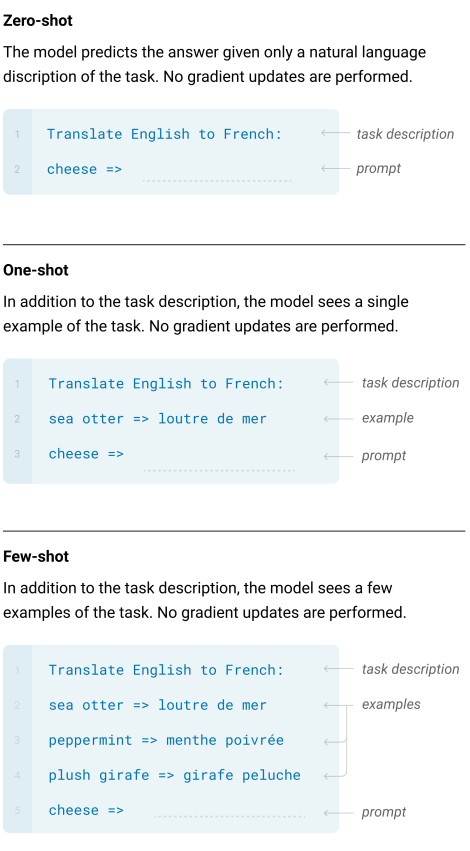

### Few shot learning with chat completion



In [ ]:
[
    {"role": "system", "content": "You are a translator that translates English sentences to French."},
    {"role": "user", "content": "Translate 'Hello' to French."},
    {"role": "assistant", "content": "Bonjour"},
    {"role": "user", "content": "Translate 'Goodbye' to French."},
    {"role": "assistant", "content": "Au revoir"},
    {"role": "user", "content": "Translate 'Thank you' to French."}
]

## GPT-3 API를 사용한 Few-shot Learning

- 예시가 모델에 제공되므로써, 모델은 해당 예시의 패턴을 학습함
- 이후, 새로운 프롬프트에 대해 이전 예시와 유사한 방식으로 응답을 생성하게 됨
- 추가학습 없이도 다양한 태스크에 모델을 적용시키는데 매우 유용함

**Prompt Enginerring**
https://platform.openai.com/docs/guides/prompt-engineering <br>

**Prompt Examples**
https://platform.openai.com/docs/examples

In [7]:
!pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.2/325.2 kB 16.8 MB/s eta 0:00:00


In [ ]:
import openai

# OpenAI API 키 설정
openai.api_key = "your_openai_api_key"  # 여기에 자신의 API 키를 입력하세요

def gpt_few_shot(prompt, examples, max_tokens=100, temperature=0.7):
    """
    Few-Shot Learning을 활용한 GPT API 호출 함수

    Args:
        prompt (str): 새로운 질문이나 요청에 대한 프롬프트.
        examples (list): (질문, 답변) 형식의 예제 리스트. 예시를 통해 모델이 학습하도록 함.
        max_tokens (int): 생성할 최대 토큰 수.
        temperature (float): 생성의 다양성을 조절하는 값 (0.0 ~ 1.0).

    Returns:
        str: 모델이 생성한 응답.
    """

    # few-shot 예제 형식 만들기
    formatted_examples = ""
    for example in examples:
        question, answer = example
        formatted_examples += f"Q: {question}\nA: {answer}\n\n"

    # 최종 프롬프트 생성 (예제 + 새로운 질문)
    full_prompt = formatted_examples + f"Q: {prompt}\nA:"

    # OpenAI API 호출
    response = openai.Completion.create(
        engine="text-davinci-003",  # 사용할 엔진 (text-davinci-003 등)
        prompt=full_prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        stop=["\n"]  # 답변의 끝을 나타내는 구분자
    )

    # 생성된 응답 반환
    return response.choices[0].text.strip()

# 예제 데이터 (Few-Shot Examples)
examples = [
    ("What is the capital of France?", "The capital of France is Paris."),
    ("Who wrote 'Pride and Prejudice'?", "Jane Austen wrote 'Pride and Prejudice'."),
    ("What is the largest planet in our solar system?", "The largest planet in our solar system is Jupiter.")
]

# 새로운 질문에 대한 프롬프트
new_prompt = "What is the chemical formula for water?"

# Few-Shot Learning을 활용한 API 호출
response = gpt_few_shot(new_prompt, examples)
print("Generated Response:", response)
